In [187]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print("Gpu enabled: ", torch.cuda.is_available())
print(torch.__version__)

Gpu enabled:  True
2.11.0+cu128


In [188]:
weight = 0.5
bias = 0.5

start=0
end=1
step=0.02

X = torch.arange(start,end,step).unsqueeze(1)
y = weight * X + bias


print(X[:10], y[:10])


tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0.5500],
        [0.5600],
        [0.5700],
        [0.5800],
        [0.5900]])


In [ ]:
train_split_ratio= int(0.8 * len(X))

train_input, train_output = X[:train_split_ratio] , y[:train_split_ratio]
test_input, test_output = X[train_split_ratio:] , y[train_split_ratio:]

len(train_input), len(train_output), len(test_input), len(test_output)


(5, 5, 45, 45)

In [190]:
def plot_predictions(train_input=train_input, train_output=train_output,test_input=test_input, test_output=test_output, predictions=None):
    plt.figure(figsize=(10,6)) # width , height

    plt.scatter(train_input, train_output, s=8, c="b", label="Training Data")
    plt.scatter(test_input, test_output, s=8, c="g", label="Test Data")

    if predictions is not None:
        plt.scatter(test_input,predictions, s=8, c="r", label="Predictions")

    plt.legend(prop={"size": 14})


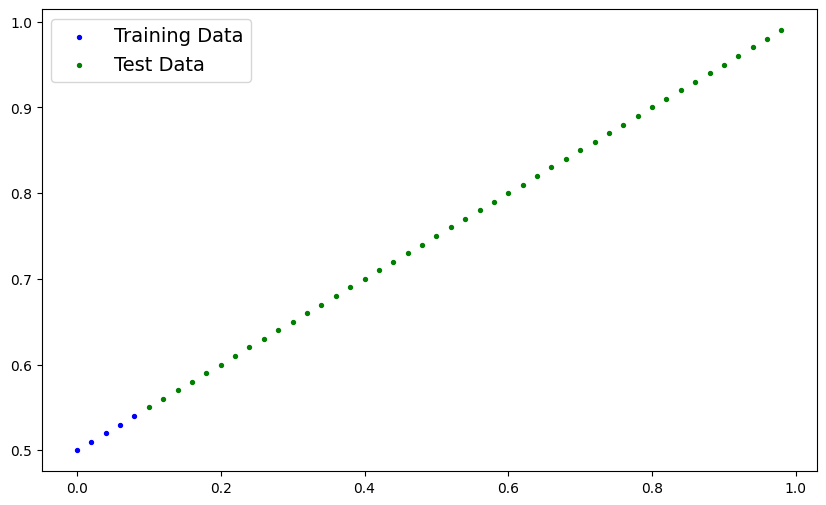

In [191]:
plot_predictions()

In [192]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))

    def forward(self, x:torch.Tensor):
        return self.weights*x +self.bias

In [193]:
torch.manual_seed(42)
model = LinearRegression()
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


tensor([[0.1625],
        [0.1692],
        [0.1759],
        [0.1827],
        [0.1894],
        [0.1961],
        [0.2029],
        [0.2096],
        [0.2163],
        [0.2231],
        [0.2298],
        [0.2366],
        [0.2433],
        [0.2500],
        [0.2568],
        [0.2635],
        [0.2702],
        [0.2770],
        [0.2837],
        [0.2904],
        [0.2972],
        [0.3039],
        [0.3106],
        [0.3174],
        [0.3241],
        [0.3308],
        [0.3376],
        [0.3443],
        [0.3510],
        [0.3578],
        [0.3645],
        [0.3712],
        [0.3780],
        [0.3847],
        [0.3914],
        [0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


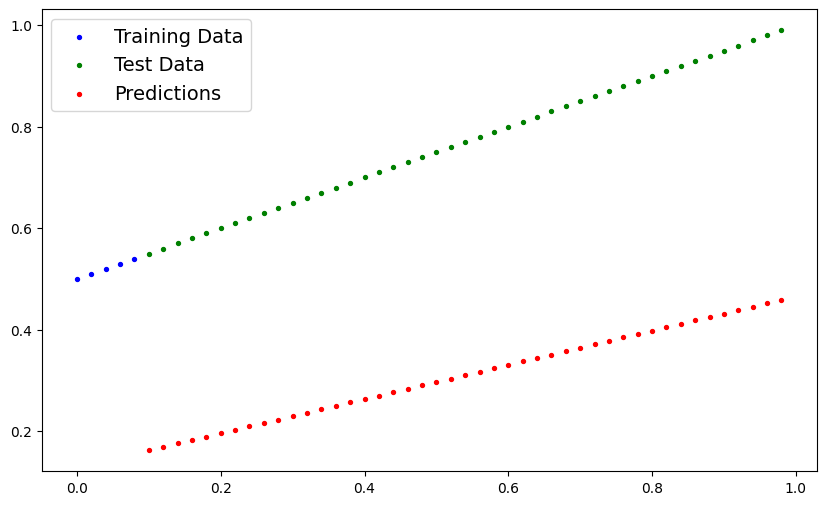

In [194]:
with torch.inference_mode():
    y_preds = model(test_input)

print(y_preds)
plot_predictions(predictions=y_preds)

In [195]:
# Check the predictions
print(f"Number of testing samples: {len(test_input)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 45
Number of predictions made: 45
Predicted values:
tensor([[0.1625],
        [0.1692],
        [0.1759],
        [0.1827],
        [0.1894],
        [0.1961],
        [0.2029],
        [0.2096],
        [0.2163],
        [0.2231],
        [0.2298],
        [0.2366],
        [0.2433],
        [0.2500],
        [0.2568],
        [0.2635],
        [0.2702],
        [0.2770],
        [0.2837],
        [0.2904],
        [0.2972],
        [0.3039],
        [0.3106],
        [0.3174],
        [0.3241],
        [0.3308],
        [0.3376],
        [0.3443],
        [0.3510],
        [0.3578],
        [0.3645],
        [0.3712],
        [0.3780],
        [0.3847],
        [0.3914],
        [0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [196]:
# calculating loss
print(torch.mean(torch.abs(test_output - y_preds))) # same as nn.L1Loss()
print(test_output - y_preds)
loss_fn = nn.L1Loss() # MAE loss is same as L1loss

optimizer = torch.optim.SGD(params=model.parameters(), # parameters of target model to optimize 
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


tensor(0.4594)
tensor([[0.3875],
        [0.3908],
        [0.3941],
        [0.3973],
        [0.4006],
        [0.4039],
        [0.4071],
        [0.4104],
        [0.4137],
        [0.4169],
        [0.4202],
        [0.4234],
        [0.4267],
        [0.4300],
        [0.4332],
        [0.4365],
        [0.4398],
        [0.4430],
        [0.4463],
        [0.4496],
        [0.4528],
        [0.4561],
        [0.4594],
        [0.4626],
        [0.4659],
        [0.4692],
        [0.4724],
        [0.4757],
        [0.4790],
        [0.4822],
        [0.4855],
        [0.4888],
        [0.4920],
        [0.4953],
        [0.4986],
        [0.5018],
        [0.5051],
        [0.5084],
        [0.5116],
        [0.5149],
        [0.5182],
        [0.5214],
        [0.5247],
        [0.5280],
        [0.5312]])


In [197]:
# now here we go for model training, we will update our model parameter(weights, bias) according to our data to match the near exact predictions we want.

epochs=2000
torch.manual_seed(42)
for epoch in range(epochs):
    model.train()

    model_predicton = model(train_input)
    loss = loss_fn(model_predicton,train_output)
    print("Calculating Loss Epoch number", epoch, "Loss: ", loss.detach().numpy())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()

Calculating Loss Epoch number 0 Loss:  0.37772298
Calculating Loss Epoch number 1 Loss:  0.36770698
Calculating Loss Epoch number 2 Loss:  0.35769096
Calculating Loss Epoch number 3 Loss:  0.34767497
Calculating Loss Epoch number 4 Loss:  0.33765894
Calculating Loss Epoch number 5 Loss:  0.32764295
Calculating Loss Epoch number 6 Loss:  0.31762695
Calculating Loss Epoch number 7 Loss:  0.30761093
Calculating Loss Epoch number 8 Loss:  0.29759493
Calculating Loss Epoch number 9 Loss:  0.2875789
Calculating Loss Epoch number 10 Loss:  0.27756292
Calculating Loss Epoch number 11 Loss:  0.2675469
Calculating Loss Epoch number 12 Loss:  0.2575309
Calculating Loss Epoch number 13 Loss:  0.24751489
Calculating Loss Epoch number 14 Loss:  0.23749891
Calculating Loss Epoch number 15 Loss:  0.22748291
Calculating Loss Epoch number 16 Loss:  0.21746695
Calculating Loss Epoch number 17 Loss:  0.20745094
Calculating Loss Epoch number 18 Loss:  0.19743495
Calculating Loss Epoch number 19 Loss:  0.18

tensor([[0.5508],
        [0.5592],
        [0.5676],
        [0.5760],
        [0.5844],
        [0.5929],
        [0.6013],
        [0.6097],
        [0.6181],
        [0.6265],
        [0.6349],
        [0.6433],
        [0.6517],
        [0.6601],
        [0.6685],
        [0.6769],
        [0.6853],
        [0.6937],
        [0.7021],
        [0.7105],
        [0.7189],
        [0.7273],
        [0.7357],
        [0.7441],
        [0.7525],
        [0.7609],
        [0.7693],
        [0.7777],
        [0.7861],
        [0.7946],
        [0.8030],
        [0.8114],
        [0.8198],
        [0.8282],
        [0.8366],
        [0.8450],
        [0.8534],
        [0.8618],
        [0.8702],
        [0.8786],
        [0.8870],
        [0.8954],
        [0.9038],
        [0.9122],
        [0.9206]])


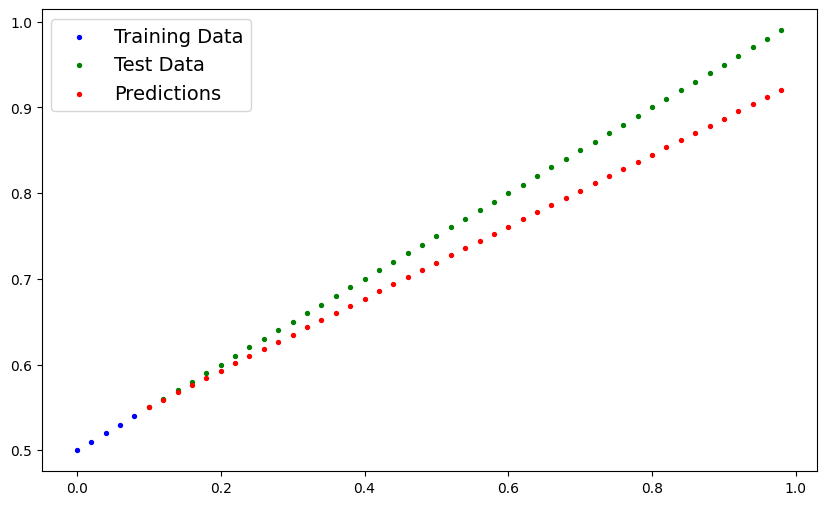

In [198]:
with torch.inference_mode():
    y_preds = model(test_input)

print(y_preds)
plot_predictions(predictions=y_preds)

In [199]:
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.4202]), 'bias': tensor([0.5088])})
[Parameter containing:
tensor([0.4202], requires_grad=True), Parameter containing:
tensor([0.5088], requires_grad=True)]
